In [3]:
import sys
import rasterio
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("Rasterio:", rasterio.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: /mnt/c/Users/allea/Downloads/Ahon Pipeline/AHON-Pipeline/.venv-gis-linux/bin/python
Rasterio: 1.5.2
NumPy: 2.5.3
Pandas: 3.0.6


In [8]:
from pathlib import Path

RAW_DIR = Path("../../../data/raw/chc_chirps")

print("Raw directory:", RAW_DIR.resolve())
print("Exists:", RAW_DIR.exists())

Raw directory: /mnt/c/Users/allea/Downloads/Ahon Pipeline/AHON-Pipeline/data/raw/chc_chirps
Exists: True


In [9]:
files = sorted(RAW_DIR.glob("chirps-v3.0.*.tif"))

print(f"Found {len(files)} CHIRPS files:")

for file in files:
    print(file)

Found 3 CHIRPS files:
../../../data/raw/chc_chirps/chirps-v3.0.2018.01.tif
../../../data/raw/chc_chirps/chirps-v3.0.2018.02.tif
../../../data/raw/chc_chirps/chirps-v3.0.2018.03.tif


In [11]:
def profile_chirps_raster(file_path):
    with rasterio.open(file_path) as src:
        data = src.read(1)

        # CHIRPS uses -9999 as the bad-value marker
        nodata_mask = data == -9999
        valid = data[~nodata_mask]

        total_cells = data.size
        nodata_cells = nodata_mask.sum()

        return {
            "file": file_path.name,
            "width": src.width,
            "height": src.height,
            "bands": src.count,
            "crs": str(src.crs),
            "resolution_x": src.res[0],
            "resolution_y": src.res[1],
            "dtype": src.dtypes[0],
            "total_cells": total_cells,
            "valid_cells": valid.size,
            "nodata_cells": nodata_cells,
            "valid_pct": valid.size / total_cells * 100,
            "nodata_pct": nodata_cells / total_cells * 100,
            "min_mm": valid.min(),
            "max_mm": valid.max(),
            "mean_mm": valid.mean(),
            "median_mm": np.median(valid),
            "std_mm": valid.std(),
            "zero_cells": (valid == 0).sum(),
            "zero_pct_valid": (valid == 0).sum() / valid.size * 100,
        }

In [12]:
profiles = []

for file in files:
    profiles.append(profile_chirps_raster(file))

profile_df = pd.DataFrame(profiles)

profile_df

,file,width,height,bands,crs,resolution_x,resolution_y,dtype,total_cells,valid_cells,nodata_cells,valid_pct,nodata_pct,min_mm,max_mm,mean_mm,median_mm,std_mm,zero_cells,zero_pct_valid
0,chirps-v3.0.2018.01.tif,7200,2400,1,EPSG:4326,0.05,0.05,float32,17280000,4848282,12431718,28.057188,71.942813,0.0,1909.378540,72.693924,26.876663,110.710518,518199,10.688302
1,chirps-v3.0.2018.02.tif,7200,2400,1,EPSG:4326,0.05,0.05,float32,17280000,4848282,12431718,28.057188,71.942813,0.0,1687.094604,71.010498,29.281300,101.928215,364014,7.508103
2,chirps-v3.0.2018.03.tif,7200,2400,1,EPSG:4326,0.05,0.05,float32,17280000,4848282,12431718,28.057188,71.942813,0.0,1818.714722,75.681190,35.609352,98.880997,343318,7.081230


In [13]:
profile_df["year"] = (
    profile_df["file"]
    .str.extract(r"chirps-v3\.0\.(\d{4})\.")[0]
    .astype(int)
)

profile_df["month"] = (
    profile_df["file"]
    .str.extract(r"chirps-v3\.0\.\d{4}\.(\d{2})")[0]
    .astype(int)
)

profile_df["date"] = pd.to_datetime(
    profile_df[["year", "month"]].assign(day=1)
)

profile_df

,file,width,height,bands,crs,resolution_x,resolution_y,dtype,total_cells,valid_cells,...,min_mm,max_mm,mean_mm,median_mm,std_mm,zero_cells,zero_pct_valid,year,month,date
0,chirps-v3.0.2018.01.tif,7200,2400,1,EPSG:4326,0.05,0.05,float32,17280000,4848282,...,0.0,1909.378540,72.693924,26.876663,110.710518,518199,10.688302,2018,1,2018-01-01
1,chirps-v3.0.2018.02.tif,7200,2400,1,EPSG:4326,0.05,0.05,float32,17280000,4848282,...,0.0,1687.094604,71.010498,29.281300,101.928215,364014,7.508103,2018,2,2018-02-01
2,chirps-v3.0.2018.03.tif,7200,2400,1,EPSG:4326,0.05,0.05,float32,17280000,4848282,...,0.0,1818.714722,75.681190,35.609352,98.880997,343318,7.081230,2018,3,2018-03-01


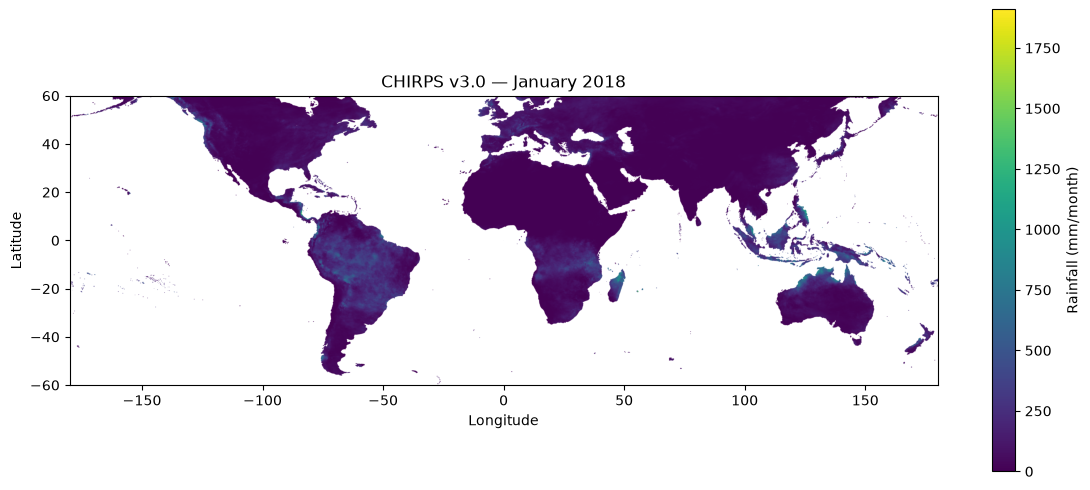

In [14]:
import matplotlib.pyplot as plt

file = files[0]

with rasterio.open(file) as src:
    data = src.read(1)
    bounds = src.bounds

data_masked = np.ma.masked_where(data == -9999, data)

plt.figure(figsize=(14, 6))

plt.imshow(
    data_masked,
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top
    ],
    origin="upper"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("CHIRPS v3.0 — January 2018")

plt.colorbar(label="Rainfall (mm/month)")

plt.show()

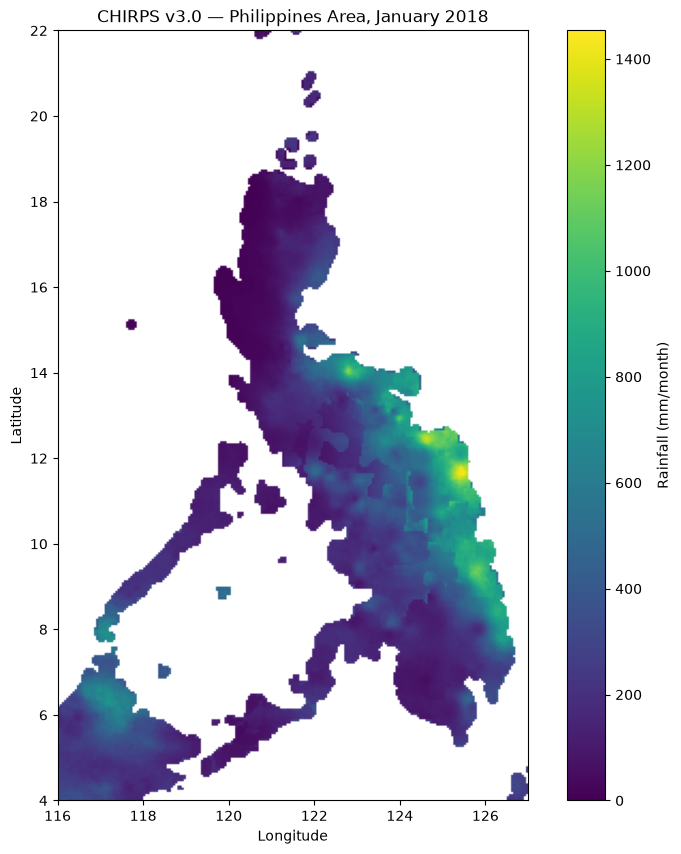

In [15]:
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

PH_BOUNDS = {
    "west": 116,
    "south": 4,
    "east": 127,
    "north": 22,
}

file = files[0]

with rasterio.open(file) as src:
    window = from_bounds(
        PH_BOUNDS["west"],
        PH_BOUNDS["south"],
        PH_BOUNDS["east"],
        PH_BOUNDS["north"],
        src.transform,
    )

    ph_data = src.read(1, window=window)
    ph_transform = src.window_transform(window)

ph_data_masked = np.ma.masked_where(
    ph_data == -9999,
    ph_data
)

plt.figure(figsize=(10, 10))

plt.imshow(
    ph_data_masked,
    extent=[
        PH_BOUNDS["west"],
        PH_BOUNDS["east"],
        PH_BOUNDS["south"],
        PH_BOUNDS["north"],
    ],
    origin="upper",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("CHIRPS v3.0 — Philippines Area, January 2018")

plt.colorbar(label="Rainfall (mm/month)")

plt.show()

In [4]:
from pathlib import Path

project_root = Path.cwd().parents[2]

bronze_dir = (
    project_root
    / "src"
    / "dataset"
    / "chc_chirps"
    / "bronze"
)

print("Bronze directory:")
print(bronze_dir)

Bronze directory:
/mnt/c/Users/allea/Downloads/Ahon Pipeline/AHON-Pipeline/src/dataset/chc_chirps/bronze


In [7]:
from pathlib import Path

project_root = Path.cwd().parents[2]

chirps_dir = (
    project_root
    / "src"
    / "dataset"
    / "chc_chirps"
)

raw_dir = chirps_dir / "raw"
bronze_dir = chirps_dir / "bronze"

bronze_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("CHIRPS directory:")
print(chirps_dir)

print("\nRaw files:")
for file in sorted(raw_dir.glob("*.tif")):
    print(" -", file.name)

print("\nBronze files:")
for file in sorted(bronze_dir.glob("*.tif")):
    print(" -", file.name)

CHIRPS directory:
/mnt/c/Users/allea/Downloads/Ahon Pipeline/AHON-Pipeline/src/dataset/chc_chirps

Raw files:

Bronze files:


In [9]:
from pathlib import Path

project_root = Path.cwd().parents[2]

chirps_dir = (
    project_root
    / "src"
    / "sql"
    / "datasets"
    / "chc_chirps"
)

raw_dir = chirps_dir / "raw"
bronze_dir = chirps_dir / "bronze"

bronze_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("CHIRPS directory:")
print(chirps_dir)

print("\nRaw files:")
for file in sorted(raw_dir.glob("*.tif")):
    print(" -", file.name)

print("\nBronze files:")
for file in sorted(bronze_dir.glob("*.tif")):
    print(" -", file.name)

CHIRPS directory:
/mnt/c/Users/allea/Downloads/Ahon Pipeline/AHON-Pipeline/src/sql/datasets/chc_chirps

Raw files:
 - chirps-v3.0.2018.01.tif
 - chirps-v3.0.2018.02.tif
 - chirps-v3.0.2018.03.tif

Bronze files:


In [13]:
request = Request(
    source_url,
    method="HEAD"
)

with urlopen(request, timeout=30) as response:
    print("Status code:", response.status)
    print("Content length:", response.headers.get("Content-Length"))
    print("Content type:", response.headers.get("Content-Type"))

Status code: 200
Content length: 22851876
Content type: image/tiff
